# Tarea 2 — Fundamentos Matemáticos para la IA (IMT3850)

**Pontificia Universidad Católica de Chile** — Instituto de Ingeniería Matemática y Computacional

**Magíster en Inteligencia Artificial** — Prof. Manuel A. Sánchez

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
from scipy import stats

np.random.seed(42)
sys.setrecursionlimit(20000)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## Pregunta 1: Variables Aleatorias (5 puntos)

**Enunciado:** Suponga que $x$ e $y$ son variables aleatorias independientes con media 0 y varianza 1. ¿Cuál es la media $\mu_Z$ y la matriz de covarianza de $Z = (x,\, y,\, ax + by)$, con $a, b \in \mathbb{R}$?

### Solución

**Datos:** $E[x] = E[y] = 0$, $\text{Var}(x) = \text{Var}(y) = 1$, $x \perp y$ (independientes).

---
**Media de $Z$:**

$$\mu_Z = E[Z] = \begin{pmatrix} E[x] \\ E[y] \\ aE[x] + bE[y] \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \\ 0 \end{pmatrix}$$

---
**Matriz de covarianza $\Sigma_Z$:**

Como $E[Z] = 0$, tenemos $\Sigma_Z = E[ZZ^\top]$.

- $\Sigma_{11} = \text{Var}(x) = 1$
- $\Sigma_{22} = \text{Var}(y) = 1$
- $\Sigma_{33} = \text{Var}(ax+by) = a^2\text{Var}(x) + b^2\text{Var}(y) + 2ab\,\text{Cov}(x,y) = a^2 + b^2$
- $\Sigma_{12} = \text{Cov}(x, y) = 0$ (independencia)
- $\Sigma_{13} = \text{Cov}(x, ax+by) = a\,\text{Var}(x) + b\,\text{Cov}(x,y) = a$
- $\Sigma_{23} = \text{Cov}(y, ax+by) = a\,\text{Cov}(y,x) + b\,\text{Var}(y) = b$

$$\boxed{\mu_Z = \begin{pmatrix}0\\0\\0\end{pmatrix}, \quad \Sigma_Z = \begin{pmatrix} 1 & 0 & a \\ 0 & 1 & b \\ a & b & a^2 + b^2 \end{pmatrix}}$$

**Nota:** $\det(\Sigma_Z) = (a^2+b^2) - a^2 - b^2 = 0$, la matriz es singular ya que la tercera componente es combinación lineal de las dos primeras.

In [2]:
# Verificacion numerica (Monte Carlo)
a, b = 2, 3
n_samples = 1_000_000
x = np.random.normal(0, 1, n_samples)
y = np.random.normal(0, 1, n_samples)
Z = np.vstack([x, y, a*x + b*y])

print('=== Pregunta 1: Verificacion Monte Carlo ===')
print(f'a = {a}, b = {b}')
print(f'Media empirica de Z: {Z.mean(axis=1).round(4)}')
print(f'Covarianza empirica:')
print(np.cov(Z).round(4))
Sigma_teo = np.array([[1, 0, a], [0, 1, b], [a, b, a**2 + b**2]])
print(f'Covarianza teorica:')
print(Sigma_teo)
print(f'det(Sigma) = {np.linalg.det(Sigma_teo):.6f}')

=== Pregunta 1: Verificacion Monte Carlo ===
a = 2, b = 3
Media empirica de Z: [-0.0016 -0.0002 -0.0039]
Covarianza empirica:
[[1.00040e+00 9.00000e-04 2.00350e+00]
 [9.00000e-04 1.00260e+00 3.00960e+00]
 [2.00350e+00 3.00960e+00 1.30358e+01]]
Covarianza teorica:
[[ 1  0  2]
 [ 0  1  3]
 [ 2  3 13]]
det(Sigma) = 0.000000


---
## Pregunta 2: Algoritmo Random Quicksort (15 puntos)

### a) Implementación del Quicksort Aleatorio

In [3]:
def random_quicksort(S):
    """Quicksort con pivot aleatorio. Retorna (lista_ordenada, comparaciones)."""
    comparisons = [0]

    def _qsort(arr):
        if len(arr) <= 1:
            return list(arr)
        pivot_idx = np.random.randint(len(arr))
        pivot = arr[pivot_idx]
        L, R = [], []
        for i, x in enumerate(arr):
            if i == pivot_idx:
                continue
            comparisons[0] += 1
            if x < pivot:
                L.append(x)
            else:
                R.append(x)
        return _qsort(L) + [pivot] + _qsort(R)

    result = _qsort(list(S))
    return result, comparisons[0]

# Test con la lista del enunciado
S = [0, 5, 4, 1, 7, 6, 3, 2, 8, 9]
sorted_S, comps = random_quicksort(S)
print(f'Lista original:  {S}')
print(f'Lista ordenada:  {sorted_S}')
print(f'Comparaciones:   {comps}')
print(f'Correcta: {sorted_S == sorted(S)}')

Lista original:  [0, 5, 4, 1, 7, 6, 3, 2, 8, 9]
Lista ordenada:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Comparaciones:   29
Correcta: True


### b-c) Experimentos y Gráfico

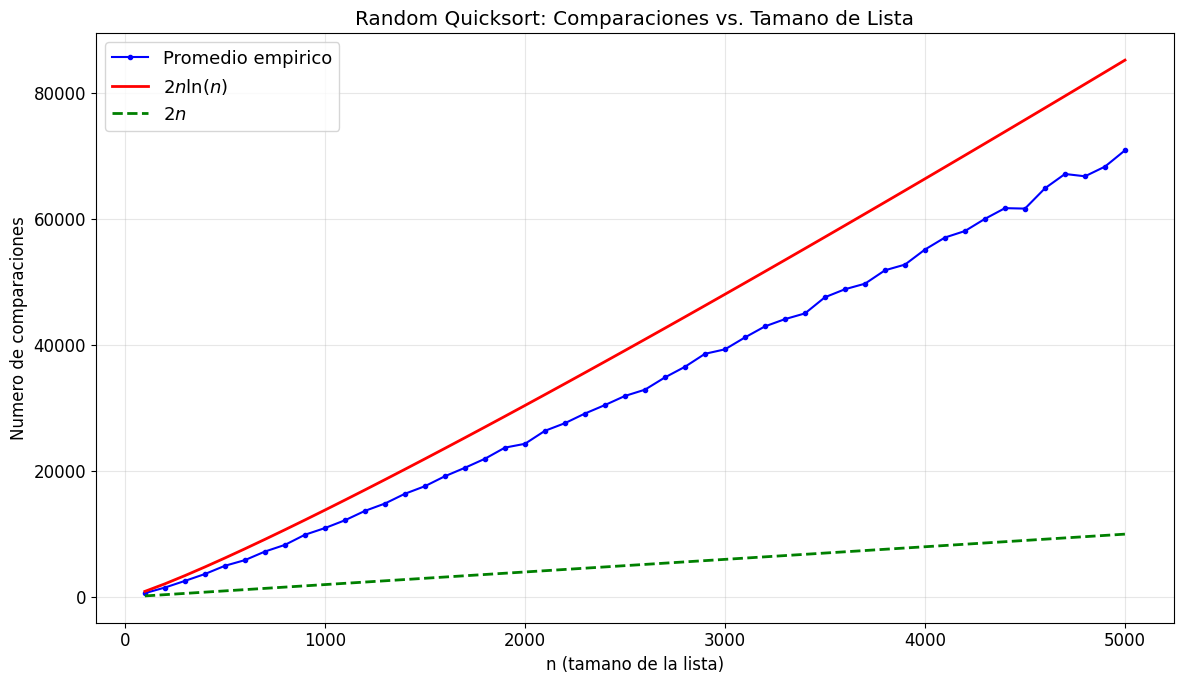

     n |     Empirico |     2n*ln(n) |       2n |    Ratio
-------------------------------------------------------
   100 |        642.1 |        921.0 |      200 |   0.6972
  1100 |      12196.2 |      15406.7 |     2200 |   0.7916
  2100 |      26387.1 |      32128.7 |     4200 |   0.8213
  3100 |      41195.6 |      49842.8 |     6200 |   0.8265
  4100 |      57040.2 |      68213.7 |     8200 |   0.8362


In [4]:
n_values = list(range(100, 5001, 100))
n_trials = 30
avg_comparisons = []

for n in n_values:
    total_comps = 0
    for _ in range(n_trials):
        S = list(np.random.permutation(n))
        _, comps = random_quicksort(S)
        total_comps += comps
    avg_comparisons.append(total_comps / n_trials)

avg_comparisons = np.array(avg_comparisons)
n_arr = np.array(n_values)
y_2nlogn = 2 * n_arr * np.log(n_arr)
y_2n = 2 * n_arr

plt.figure(figsize=(12, 7))
plt.plot(n_arr, avg_comparisons, 'bo-', markersize=3, label='Promedio empirico', linewidth=1.5)
plt.plot(n_arr, y_2nlogn, 'r-', label=r'$2n\ln(n)$', linewidth=2)
plt.plot(n_arr, y_2n, 'g--', label=r'$2n$', linewidth=2)
plt.xlabel('n (tamano de la lista)')
plt.ylabel('Numero de comparaciones')
plt.title('Random Quicksort: Comparaciones vs. Tamano de Lista')
plt.legend(fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla resumen
print(f'{"n":>6} | {"Empirico":>12} | {"2n*ln(n)":>12} | {"2n":>8} | {"Ratio":>8}')
print('-' * 55)
for i in range(0, len(n_values), 10):
    n = n_values[i]
    emp = avg_comparisons[i]
    teo = y_2nlogn[i]
    print(f'{n:>6} | {emp:>12.1f} | {teo:>12.1f} | {2*n:>8} | {emp/teo:>8.4f}')

### d) Explicación

Los resultados corroboran los resultados teóricos:

1. **Crecimiento $O(n \ln n)$:** El promedio empírico sigue de cerca la curva $y = 2n\ln(n)$, confirmando la complejidad esperada $\Theta(n \ln n)$.

2. **Constante multiplicativa:** La razón entre el promedio empírico y $2n\ln(n)$ se mantiene cercana a 1, confirmando la constante teórica.

3. **Separación de $2n$:** El promedio empírico crece significativamente más rápido que $2n$ (lineal), confirmando el factor logarítmico.

4. **Base teórica:** $E[C] = 2nH_n \approx 2n\ln(n)$ se deriva usando variables indicadoras $X_{ij}$ con $P(X_{ij}=1) = \frac{2}{j-i+1}$.

---
## Pregunta 3: Convexidad (10 puntos)

**Enunciado:** Sea $f: \mathbb{R}^d \to \mathbb{R}$ diferenciable. Pruebe que $f$ es convexa si y sólo si:

$$f(y) \geq f(x) + \nabla f(x)^\top (y - x) \quad \forall\, x, y$$

### Demostración

#### ($\Rightarrow$) $f$ convexa $\implies$ condición de primer orden

**Hipótesis:** $f$ es convexa, i.e., $\forall\, x,y$ y $\theta \in [0,1]$:

$$f(x + \theta(y-x)) \leq (1-\theta)f(x) + \theta f(y)$$

Reordenando:

$$f(x + \theta(y-x)) - f(x) \leq \theta(f(y) - f(x))$$

$$\frac{f(x + \theta(y-x)) - f(x)}{\theta} \leq f(y) - f(x)$$

Tomando $\theta \to 0^+$:

$$\nabla f(x)^\top(y-x) \leq f(y) - f(x)$$

$$\boxed{f(y) \geq f(x) + \nabla f(x)^\top(y-x)} \; \checkmark$$

---
#### ($\Leftarrow$) Condición de primer orden $\implies$ $f$ convexa

**Hipótesis:** $f(y) \geq f(x) + \nabla f(x)^\top(y-x) \quad (*)$

Sea $z = \theta y + (1-\theta)x$ para $\theta \in [0,1]$. Aplicamos $(*)$ desde $z$:

1. Con $x \leftarrow z,\; y \leftarrow y$:
$$f(y) \geq f(z) + \nabla f(z)^\top(y - z) \quad \text{(i)}$$

2. Con $x \leftarrow z,\; y \leftarrow x$:
$$f(x) \geq f(z) + \nabla f(z)^\top(x - z) \quad \text{(ii)}$$

Multiplicamos (i) por $\theta$ y (ii) por $(1-\theta)$ y sumamos:

$$\theta f(y) + (1-\theta)f(x) \geq f(z) + \nabla f(z)^\top\underbrace{[\theta(y-z) + (1-\theta)(x-z)]}_{= \theta y + (1-\theta)x - z = 0}$$

Por lo tanto:

$$\boxed{\theta f(y) + (1-\theta)f(x) \geq f(\theta y + (1-\theta)x)} \; \checkmark$$

Esto demuestra que $f$ es convexa. $\blacksquare$

---
## Pregunta 4: Descenso de Gradiente (15 puntos)

Minimizar $L(\theta) = \frac{1}{2N}\|X\theta - y\|^2$ con:
- Gradiente: $\nabla L(\theta) = \frac{1}{N}X^\top(X\theta - y)$
- Hessiano: $H = \frac{1}{N}X^\top X$

### Implementación de Funciones

In [5]:
# ===== Funciones de descenso de gradiente =====

def gradient_descent(X, y, NITMAX, gamma_fn, theta0=None, max_loss=1e15):
    """Descenso de gradiente determinista."""
    N, D = X.shape
    H = X.T @ X / N
    theta = theta0.copy() if theta0 is not None else np.zeros(D)
    losses = []
    for t in range(NITMAX):
        r = X @ theta - y
        loss = 0.5 / N * np.dot(r, r)
        losses.append(loss)
        if loss > max_loss or np.isnan(loss):
            break
        g = X.T @ r / N
        if np.linalg.norm(g) < 1e-12:
            break
        lr = gamma_fn(g, H, t)
        theta = theta - lr * g
    r = X @ theta - y
    losses.append(0.5 / N * np.dot(r, r))
    return theta, losses

def sgd(X, y, NITMAX, gamma_fn, theta0=None, max_loss=1e15):
    """Descenso de gradiente estocastico."""
    N, D = X.shape
    H = X.T @ X / N
    theta = theta0.copy() if theta0 is not None else np.zeros(D)
    losses = []
    for t in range(NITMAX):
        if t % 10 == 0:
            r = X @ theta - y
            loss = 0.5 / N * np.dot(r, r)
            losses.append(loss)
            if loss > max_loss or np.isnan(loss):
                break
        i = np.random.randint(N)
        xi = X[i]
        gi = xi * (xi @ theta - y[i])
        lr = gamma_fn(gi, H, t)
        theta = theta - lr * gi
    r = X @ theta - y
    losses.append(0.5 / N * np.dot(r, r))
    return theta, losses

# ===== Tasas de aprendizaje =====

def gamma_clases_gd(g, H, t):
    """Exact line search para GD: gamma = g^T g / (g^T H g)"""
    gHg = g @ H @ g
    if gHg < 1e-15:
        return 0.0
    return (g @ g) / gHg

def make_gamma_clases_sgd(X):
    """Step 1/L_max para SGD, donde L_max = max_i ||x_i||^2.
    Garantiza estabilidad para gradientes estocasticos individuales."""
    L_max = np.max(np.sum(X**2, axis=1))
    def gamma_fn(g, H, t):
        return 1.0 / L_max
    return gamma_fn

def gamma_log(g, H, t):
    """gamma(t) = log(t+2)"""
    return np.log(t + 2)

print('Funciones definidas correctamente.')
print('gamma_clases GD: exact line search (optimo para cuadraticas)')
print('gamma_clases SGD: 1/L_max (estable para gradientes individuales)')

Funciones definidas correctamente.
gamma_clases GD: exact line search (optimo para cuadraticas)
gamma_clases SGD: 1/L_max (estable para gradientes individuales)


### c) Experimentos con datos lineales

$X \in \mathbb{R}^{N \times 2}$, $\theta \in \mathbb{R}^2$

Solucion analitica: theta* = [2.2104 2.9844], Loss = 1.867652
GD (gamma_clases): theta = [2.2104 2.9844], Loss = 1.867652
GD (gamma=log): DIVERGE (loss = 1.82e+18)


SGD avg (gamma_clases): theta = [2.192  3.0032], Loss avg = 2.211705
SGD avg (gamma=log): DIVERGE


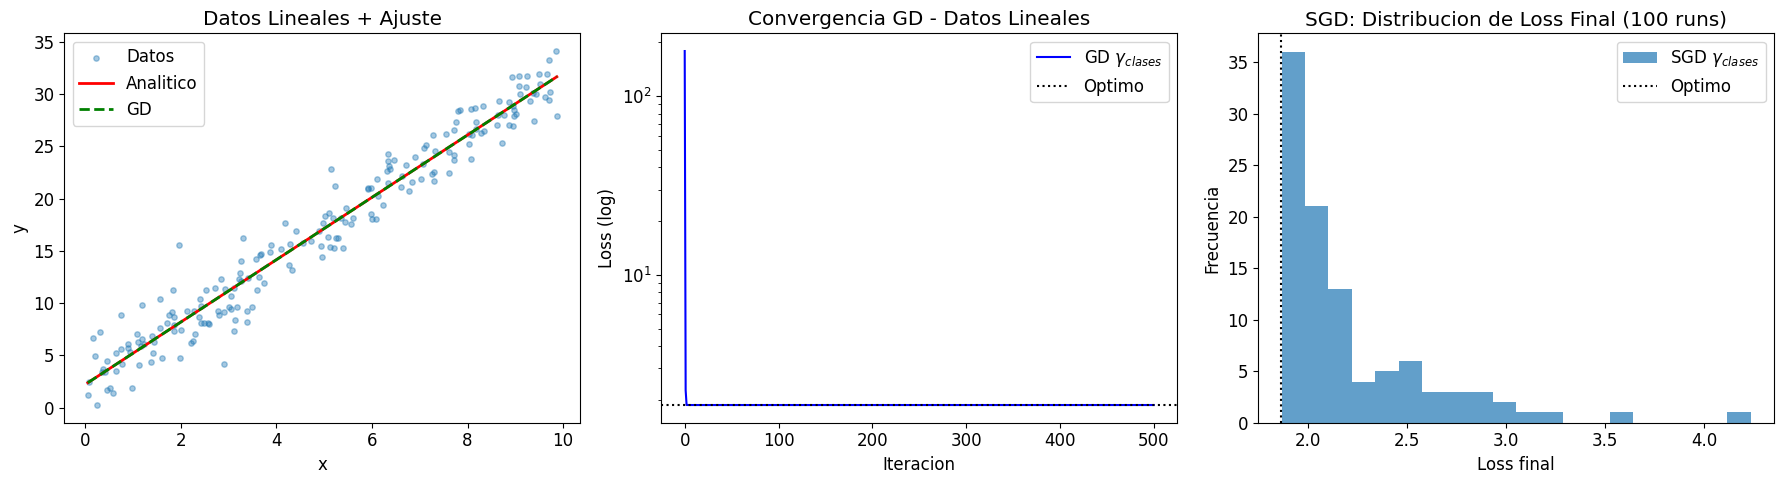

In [6]:
# Cargar datos lineales
df_lin = pd.read_csv('datos_lineales.csv')
x_raw = df_lin['x'].values
y_raw = df_lin['y'].values
N = len(x_raw)
X_lin = np.column_stack([np.ones(N), x_raw])  # [1, x]

# Solucion analitica
theta_star = np.linalg.lstsq(X_lin, y_raw, rcond=None)[0]
loss_star = 0.5/N * np.linalg.norm(X_lin @ theta_star - y_raw)**2
print(f'Solucion analitica: theta* = {theta_star.round(4)}, Loss = {loss_star:.6f}')

NITMAX_GD = 500
NITMAX_SGD = 2000
theta0 = np.zeros(2)

# GD con gamma_clases (exact line search)
theta_gd_c, loss_gd_c = gradient_descent(X_lin, y_raw, NITMAX_GD, gamma_clases_gd, theta0)
print(f'GD (gamma_clases): theta = {theta_gd_c.round(4)}, Loss = {loss_gd_c[-1]:.6f}')

# GD con gamma_log
theta_gd_l, loss_gd_l = gradient_descent(X_lin, y_raw, NITMAX_GD, gamma_log, theta0)
diverged_gd_l = loss_gd_l[-1] > 1e10
if diverged_gd_l:
    print(f'GD (gamma=log): DIVERGE (loss = {loss_gd_l[-1]:.2e})')
else:
    print(f'GD (gamma=log): theta = {theta_gd_l.round(4)}, Loss = {loss_gd_l[-1]:.6f}')

# SGD: 100 ejecuciones con cada tasa
gamma_sgd_c = make_gamma_clases_sgd(X_lin)
n_runs = 100
thetas_sgd_c = []
losses_sgd_c = []
thetas_sgd_l = []
losses_sgd_l = []

for run in range(n_runs):
    t, l = sgd(X_lin, y_raw, NITMAX_SGD, gamma_sgd_c, theta0)
    thetas_sgd_c.append(t)
    losses_sgd_c.append(l[-1])
    t, l = sgd(X_lin, y_raw, NITMAX_SGD, gamma_log, theta0)
    thetas_sgd_l.append(t)
    losses_sgd_l.append(l[-1])

thetas_sgd_c = np.array(thetas_sgd_c)
thetas_sgd_l = np.array(thetas_sgd_l)

print(f'SGD avg (gamma_clases): theta = {thetas_sgd_c.mean(axis=0).round(4)}, '
      f'Loss avg = {np.mean(losses_sgd_c):.6f}')

sgd_l_diverged = np.mean(losses_sgd_l) > 1e10
if sgd_l_diverged:
    print(f'SGD avg (gamma=log): DIVERGE')
else:
    print(f'SGD avg (gamma=log): theta = {thetas_sgd_l.mean(axis=0).round(4)}, '
          f'Loss avg = {np.mean(losses_sgd_l):.6f}')

# === Graficos ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Datos + ajuste
axes[0].scatter(x_raw, y_raw, alpha=0.4, s=15, label='Datos')
x_plot = np.linspace(x_raw.min(), x_raw.max(), 100)
axes[0].plot(x_plot, theta_star[0] + theta_star[1]*x_plot, 'r-', lw=2, label='Analitico')
axes[0].plot(x_plot, theta_gd_c[0] + theta_gd_c[1]*x_plot, 'g--', lw=2, label='GD')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Datos Lineales + Ajuste')
axes[0].legend()

# Curva de loss GD
axes[1].semilogy(loss_gd_c, 'b-', label=r'GD $\gamma_{clases}$')
if not diverged_gd_l:
    axes[1].semilogy(loss_gd_l, 'r--', label=r'GD $\gamma=\log(t)$')
axes[1].axhline(y=loss_star, color='k', linestyle=':', label='Optimo')
axes[1].set_xlabel('Iteracion'); axes[1].set_ylabel('Loss (log)')
axes[1].set_title('Convergencia GD - Datos Lineales')
axes[1].legend()

# Histograma de loss final SGD
axes[2].hist(losses_sgd_c, bins=20, alpha=0.7, label=r'SGD $\gamma_{clases}$')
axes[2].axvline(x=loss_star, color='k', linestyle=':', label='Optimo')
axes[2].set_xlabel('Loss final'); axes[2].set_ylabel('Frecuencia')
axes[2].set_title('SGD: Distribucion de Loss Final (100 runs)')
axes[2].legend()

plt.tight_layout()
plt.show()

### Análisis - Datos Lineales

- **$\gamma_{clases}$:** Para GD se usa búsqueda exacta de línea ($\gamma = g^\top g / g^\top H g$), óptima para cuadráticas. Para SGD se usa $\gamma = 1/L_{\max}$ donde $L_{\max} = \max_i \|x_i\|^2$, garantizando estabilidad. GD converge exactamente; SGD oscila cerca del óptimo.

- **$\gamma(t) = \log(t+2)$:** La tasa crece sin límite, causando divergencia. Esto demuestra la importancia de $\gamma < 2/\lambda_{\max}(H)$ para convergencia.

### d) Experimentos con datos cuadráticos

$X \in \mathbb{R}^{N \times 3}$, $\theta \in \mathbb{R}^3$

Solucion analitica: theta* = [0.9616 2.0066 0.5037], Loss = 0.125752
GD (gamma_clases): theta = [0.9616 2.0066 0.5037], Loss = 0.125752
GD (gamma=log): DIVERGE


SGD avg (gamma_clases): theta = [0.9622 2.0119 0.4998], Loss avg = 0.142937
SGD avg (gamma=log): DIVERGE


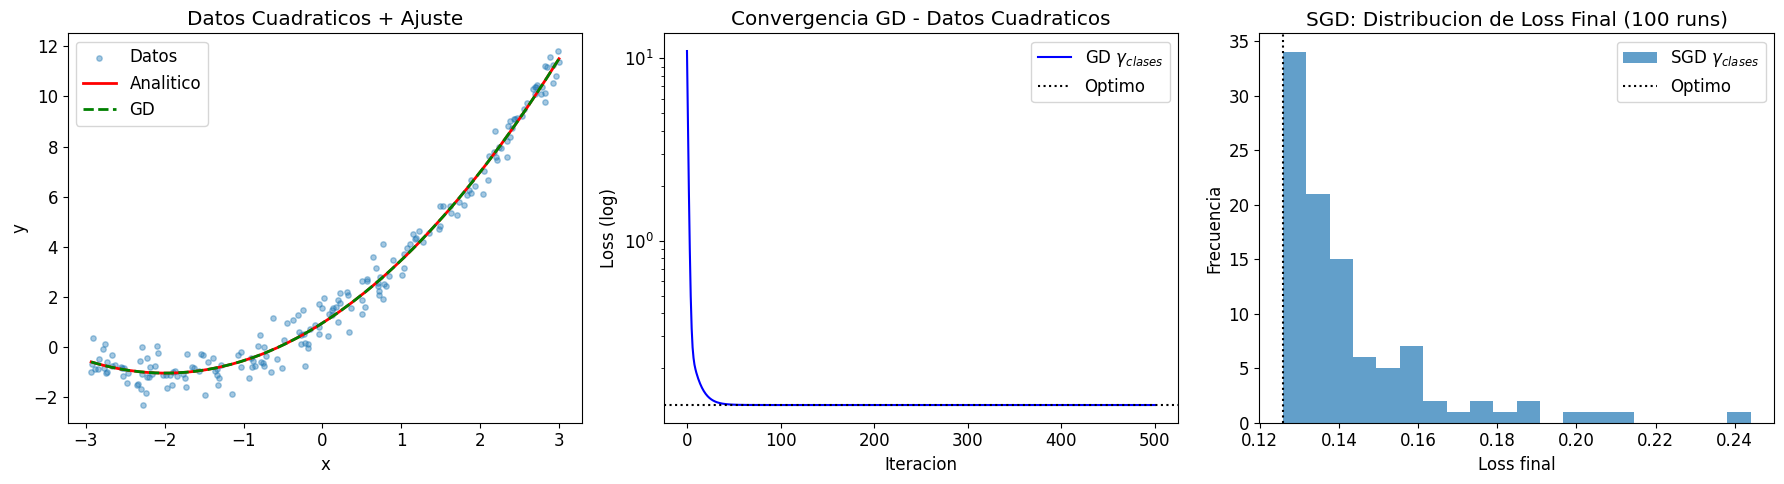

In [7]:
# Cargar datos cuadraticos
df_quad = pd.read_csv('datos_cuadraticos.csv')
x_raw_q = df_quad['x'].values
y_raw_q = df_quad['y'].values
N_q = len(x_raw_q)
X_quad = np.column_stack([np.ones(N_q), x_raw_q, x_raw_q**2])  # [1, x, x^2]

# Solucion analitica
theta_star_q = np.linalg.lstsq(X_quad, y_raw_q, rcond=None)[0]
loss_star_q = 0.5/N_q * np.linalg.norm(X_quad @ theta_star_q - y_raw_q)**2
print(f'Solucion analitica: theta* = {theta_star_q.round(4)}, Loss = {loss_star_q:.6f}')

NITMAX_GD = 500
NITMAX_SGD = 2000
theta0_q = np.zeros(3)

# GD con gamma_clases (exact line search)
theta_gd_cq, loss_gd_cq = gradient_descent(X_quad, y_raw_q, NITMAX_GD, gamma_clases_gd, theta0_q)
print(f'GD (gamma_clases): theta = {theta_gd_cq.round(4)}, Loss = {loss_gd_cq[-1]:.6f}')

# GD con gamma_log
theta_gd_lq, loss_gd_lq = gradient_descent(X_quad, y_raw_q, NITMAX_GD, gamma_log, theta0_q)
diverged_gd_lq = loss_gd_lq[-1] > 1e10
if diverged_gd_lq:
    print(f'GD (gamma=log): DIVERGE')
else:
    print(f'GD (gamma=log): theta = {theta_gd_lq.round(4)}, Loss = {loss_gd_lq[-1]:.6f}')

# SGD: 100 ejecuciones
gamma_sgd_cq = make_gamma_clases_sgd(X_quad)
thetas_sgd_cq = []
losses_sgd_cq = []
thetas_sgd_lq = []
losses_sgd_lq = []

for run in range(100):
    t, l = sgd(X_quad, y_raw_q, NITMAX_SGD, gamma_sgd_cq, theta0_q)
    thetas_sgd_cq.append(t)
    losses_sgd_cq.append(l[-1])
    t, l = sgd(X_quad, y_raw_q, NITMAX_SGD, gamma_log, theta0_q)
    thetas_sgd_lq.append(t)
    losses_sgd_lq.append(l[-1])

thetas_sgd_cq = np.array(thetas_sgd_cq)
thetas_sgd_lq = np.array(thetas_sgd_lq)

print(f'SGD avg (gamma_clases): theta = {thetas_sgd_cq.mean(axis=0).round(4)}, '
      f'Loss avg = {np.mean(losses_sgd_cq):.6f}')
sgd_lq_div = np.mean(losses_sgd_lq) > 1e10
if sgd_lq_div:
    print(f'SGD avg (gamma=log): DIVERGE')
else:
    print(f'SGD avg (gamma=log): theta = {thetas_sgd_lq.mean(axis=0).round(4)}')

# === Graficos ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Datos + ajuste
order = np.argsort(x_raw_q)
axes[0].scatter(x_raw_q, y_raw_q, alpha=0.4, s=15, label='Datos')
x_plot_q = np.sort(x_raw_q)
X_plot_q = np.column_stack([np.ones_like(x_plot_q), x_plot_q, x_plot_q**2])
axes[0].plot(x_plot_q, X_plot_q @ theta_star_q, 'r-', lw=2, label='Analitico')
axes[0].plot(x_plot_q, X_plot_q @ theta_gd_cq, 'g--', lw=2, label='GD')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Datos Cuadraticos + Ajuste')
axes[0].legend()

# Curva de loss GD
axes[1].semilogy(loss_gd_cq, 'b-', label=r'GD $\gamma_{clases}$')
if not diverged_gd_lq:
    axes[1].semilogy(loss_gd_lq, 'r--', label=r'GD $\gamma=\log(t)$')
axes[1].axhline(y=loss_star_q, color='k', linestyle=':', label='Optimo')
axes[1].set_xlabel('Iteracion'); axes[1].set_ylabel('Loss (log)')
axes[1].set_title('Convergencia GD - Datos Cuadraticos')
axes[1].legend()

# Histograma loss final SGD
axes[2].hist(losses_sgd_cq, bins=20, alpha=0.7, label=r'SGD $\gamma_{clases}$')
axes[2].axvline(x=loss_star_q, color='k', linestyle=':', label='Optimo')
axes[2].set_xlabel('Loss final'); axes[2].set_ylabel('Frecuencia')
axes[2].set_title('SGD: Distribucion de Loss Final (100 runs)')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## Pregunta 5: Garantías Estadísticas y TLC (15 puntos)

Clasificador con precisión real $p$ desconocida. Queremos estimar $p$ con $\varepsilon = 0.02$ y confianza del 95%.

### a) Cota de Chebyshev

In [8]:
# Chebyshev: P(|X_bar - p| >= eps) <= sigma^2 / (n * eps^2) <= delta
# Peor caso Bernoulli: sigma^2 = p(1-p) <= 1/4
eps = 0.02
delta = 0.05
sigma2_max = 0.25

n_cheb = int(np.ceil(sigma2_max / (eps**2 * delta)))
print('=== Chebyshev ===')
print(f'Varianza peor caso: sigma^2 = {sigma2_max}')
print(f'epsilon = {eps}, delta = {delta}')
print(f'n >= sigma^2 / (eps^2 * delta) = {sigma2_max} / ({eps**2} * {delta})')
print(f'n >= {n_cheb}')
print(f'Se necesitan al menos n = {n_cheb} muestras.')

=== Chebyshev ===
Varianza peor caso: sigma^2 = 0.25
epsilon = 0.02, delta = 0.05
n >= sigma^2 / (eps^2 * delta) = 0.25 / (0.0004 * 0.05)
n >= 12500
Se necesitan al menos n = 12500 muestras.


### b) Teorema del Límite Central

In [9]:
# CLT: P(|X_bar - p| >= eps) approx 2(1 - Phi(eps*sqrt(n)/sigma)) <= delta
# Necesitamos: eps*sqrt(n)/sigma >= z_{1-delta/2} = z_0.975 = 1.96
# Peor caso: sigma = 0.5
z_975 = 1.96
sigma_max = 0.5

sqrt_n = z_975 * sigma_max / eps
n_clt = int(np.ceil(sqrt_n**2))
print('=== Teorema del Limite Central ===')
print(f'z_0.975 = {z_975}')
print(f'sqrt(n) >= z * sigma / eps = {z_975} * {sigma_max} / {eps} = {sqrt_n}')
print(f'n >= {sqrt_n}^2 = {sqrt_n**2}')
print(f'Se necesitan al menos n = {n_clt} muestras.')
print(f'Reduccion vs Chebyshev: {n_cheb}/{n_clt} = {n_cheb/n_clt:.1f}x')

=== Teorema del Limite Central ===
z_0.975 = 1.96
sqrt(n) >= z * sigma / eps = 1.96 * 0.5 / 0.02 = 49.0
n >= 49.0^2 = 2401.0
Se necesitan al menos n = 2401 muestras.
Reduccion vs Chebyshev: 12500/2401 = 5.2x


### c-d) Simulación e Histograma

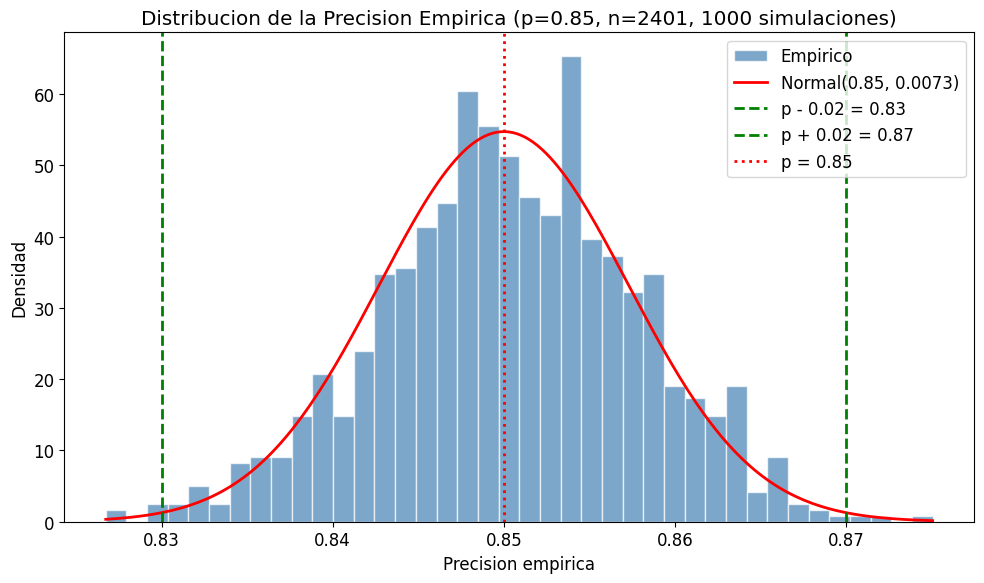

=== Parte d: Analisis ===
Fraccion empirica en [0.83, 0.87]: 0.9930 (99.3%)
Prediccion TLC (sigma real = 0.3571):
  z = eps*sqrt(n)/sigma = 0.02*49.0/0.3571 = 2.7445
  P(|X_bar - p| <= 0.02) = 2*Phi(2.7445) - 1 = 0.9939 (99.4%)
Diferencia: 0.0009

Nota: Usamos n=2401 (calculado con peor caso sigma=0.5), pero sigma real
= sqrt(0.85*0.15) = 0.3571 < 0.5.
Por eso la confianza real (~99.4%) es mucho mayor que el 95% requerido.


In [10]:
# Simulacion con p = 0.85, n del TLC
p_real = 0.85
n_test = n_clt  # del TLC
n_sims = 1000

# Generar 1000 conjuntos de prueba
np.random.seed(42)
empirical_accuracies = np.array([
    np.random.binomial(n_test, p_real) / n_test
    for _ in range(n_sims)
])

# Histograma
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(empirical_accuracies, bins=40, density=True, alpha=0.7,
        color='steelblue', edgecolor='white', label='Empirico')

# Curva teorica (Normal por TLC)
sigma_real = np.sqrt(p_real * (1 - p_real) / n_test)
x_norm = np.linspace(empirical_accuracies.min(), empirical_accuracies.max(), 200)
y_norm = stats.norm.pdf(x_norm, p_real, sigma_real)
ax.plot(x_norm, y_norm, 'r-', lw=2, label=f'Normal({p_real}, {sigma_real:.4f})')

# Lineas de referencia
ax.axvline(x=0.83, color='green', linestyle='--', lw=2, label='p - 0.02 = 0.83')
ax.axvline(x=0.87, color='green', linestyle='--', lw=2, label='p + 0.02 = 0.87')
ax.axvline(x=p_real, color='red', linestyle=':', lw=2, label=f'p = {p_real}')

ax.set_xlabel('Precision empirica')
ax.set_ylabel('Densidad')
ax.set_title(f'Distribucion de la Precision Empirica (p={p_real}, n={n_test}, {n_sims} simulaciones)')
ax.legend()
plt.tight_layout()
plt.show()

# Parte d: Fraccion en [0.83, 0.87]
fraction_in = np.mean((empirical_accuracies >= 0.83) & (empirical_accuracies <= 0.87))

# Prediccion teorica del TLC con sigma real (p=0.85)
z_val = eps / sigma_real
p_teo = 2 * stats.norm.cdf(z_val) - 1

print(f'=== Parte d: Analisis ===')
print(f'Fraccion empirica en [0.83, 0.87]: {fraction_in:.4f} ({fraction_in*100:.1f}%)')
print(f'Prediccion TLC (sigma real = {np.sqrt(p_real*(1-p_real)):.4f}):')
print(f'  z = eps*sqrt(n)/sigma = {eps}*{np.sqrt(n_test):.1f}/{np.sqrt(p_real*(1-p_real)):.4f} = {z_val:.4f}')
print(f'  P(|X_bar - p| <= 0.02) = 2*Phi({z_val:.4f}) - 1 = {p_teo:.4f} ({p_teo*100:.1f}%)')
print(f'Diferencia: {abs(fraction_in - p_teo):.4f}')
print()
print('Nota: Usamos n={} (calculado con peor caso sigma=0.5), pero sigma real'.format(n_test))
print(f'= sqrt(0.85*0.15) = {np.sqrt(p_real*(1-p_real)):.4f} < 0.5.')
print('Por eso la confianza real (~{:.1f}%) es mucho mayor que el 95% requerido.'.format(p_teo*100))

---
## Pregunta 6: Algoritmo de Mediana Aleatoria (10 puntos - Bonus)

Implementación del algoritmo aleatorio para encontrar la mediana, basado en la Clase 6.

In [11]:
def random_median(S):
    """
    Algoritmo aleatorio para encontrar la mediana.
    1. Muestrea R de tamano ceil(n^{3/4})
    2. Encuentra cotas d, u usando R
    3. Filtra C = {x in S : d <= x <= u}
    4. Si la mediana esta en C, la retorna
    5. Si no, repite
    """
    S = np.array(S, dtype=float)
    n = len(S)
    k = (n - 1) // 2  # indice de la mediana (0-indexed)
    max_iter = 100

    for attempt in range(max_iter):
        # Paso 1: Muestrear R
        R_size = int(np.ceil(n ** 0.75))
        R = np.sort(np.random.choice(S, R_size, replace=True))

        # Paso 2: Encontrar cotas
        half = R_size // 2
        offset = int(np.ceil(np.sqrt(n)))
        d_idx = max(0, half - offset)
        u_idx = min(R_size - 1, half + offset)
        d = R[d_idx]
        u = R[u_idx]

        # Paso 3: Filtrar
        C = np.sort(S[(S >= d) & (S <= u)])
        l_d = np.sum(S < d)

        # Paso 4: Verificar condiciones
        if len(C) <= 4 * n**0.75 and l_d <= k and l_d + len(C) > k:
            return float(C[k - l_d]), attempt + 1

    # Fallback: mediana exacta
    return float(np.median(S)), max_iter

# === Experimentos ===
print('=== Algoritmo de Mediana Aleatoria ===')
print(f'{"n":>8} | {"Mediana Alg":>12} | {"Mediana Real":>12} | {"Correcto":>8} | {"Intentos":>8}')
print('-' * 65)

test_sizes = [11, 101, 501, 1001, 5001, 10001]
for n in test_sizes:
    S = np.random.permutation(n).astype(float)
    med_alg, attempts = random_median(S)
    med_real = float(np.median(S))
    correct = np.isclose(med_alg, med_real)
    print(f'{n:>8} | {med_alg:>12.1f} | {med_real:>12.1f} | {str(correct):>8} | {attempts:>8}')

# Prueba masiva: 500 ejecuciones en n=1001
n_test_med = 1001
n_runs_med = 500
successes = 0
total_attempts = 0
for _ in range(n_runs_med):
    S = np.random.permutation(n_test_med).astype(float)
    med_alg, att = random_median(S)
    med_real = float(np.median(S))
    if np.isclose(med_alg, med_real):
        successes += 1
    total_attempts += att

print(f'\nPrueba masiva (n={n_test_med}, {n_runs_med} ejecuciones):')
print(f'  Exito: {successes}/{n_runs_med} ({100*successes/n_runs_med:.1f}%)')
print(f'  Intentos promedio: {total_attempts/n_runs_med:.2f}')
print(f'  Complejidad: O(n) por intento con alta probabilidad de exito.')

=== Algoritmo de Mediana Aleatoria ===
       n |  Mediana Alg | Mediana Real | Correcto | Intentos
-----------------------------------------------------------------
      11 |          5.0 |          5.0 |     True |        1
     101 |         50.0 |         50.0 |     True |        1
     501 |        250.0 |        250.0 |     True |        1
    1001 |        500.0 |        500.0 |     True |        1
    5001 |       2500.0 |       2500.0 |     True |        1
   10001 |       5000.0 |       5000.0 |     True |        1

Prueba masiva (n=1001, 500 ejecuciones):
  Exito: 500/500 (100.0%)
  Intentos promedio: 1.00
  Complejidad: O(n) por intento con alta probabilidad de exito.
